# Futures-Only Signal IC: ADR Close and Next Ordinary Open

This notebook evaluates the futures-only signal at `13:00`, `13:30`, `14:00`, `14:30`, `15:00`, `15:30`, `15:50`, and `15:59` ET.

- `ADR close` horizon: ADR NBBO mid at the entry time to ADR `PX_LAST` close.
- `Next ordinary open` horizon: ADR NBBO mid at the entry time to the converted ordinary open on the next calendar day.
- Ordinary-open exits start from `ord_open_to_usd_adr_PX_OPEN_adjust_none.csv`.
- If the next calendar day is an ordinary ex-date, the exit is adjusted by the one-day multiplier implied by `adjust_all / adjust_none`.
- Only dates with a true next-calendar-day ordinary session are kept, so Fridays and ordinary-holiday eves drop automatically.
- The notebook also compares the magnitude of `entry -> ADR close` and `entry -> next ordinary open` returns on the overlapping observations.

The notebook is standalone and does not import repo code.


In [1]:
import datetime as dt
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pandas_market_calendars as mcal
from tqdm.auto import tqdm

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)


In [2]:
DATA_DIR = Path('data') if Path('data/raw/adr_info.csv').exists() else Path('../data')
assert (DATA_DIR / 'raw' / 'adr_info.csv').exists(), 'Could not resolve data directory.'

SIGNAL_DIR = DATA_DIR / 'processed' / 'futures_only_signal'
ADR_NBBO_DIR = DATA_DIR / 'raw' / 'adrs' / 'bbo-1m' / 'nbbo'
ADR_CLOSE_FILE = DATA_DIR / 'raw' / 'adrs' / 'adr_PX_LAST_adjust_none.csv'
ORD_OPEN_NONE_FILE = DATA_DIR / 'processed' / 'ordinary' / 'ord_open_to_usd_adr_PX_OPEN_adjust_none.csv'
ORD_OPEN_ALL_FILE = DATA_DIR / 'processed' / 'ordinary' / 'ord_open_to_usd_adr_PX_OPEN_adjust_all.csv'
ADR_INFO_FILE = DATA_DIR / 'raw' / 'adr_info.csv'

ENTRY_TIMES = ['13:00', '13:30', '14:00', '14:30', '15:00', '15:30', '15:50', '15:59']
ENTRY_LOOKBACK = pd.Timedelta('30min')
MIN_OBS_TICKER = 30
NEXT_OPEN_RATIO_ATOL = 1e-5
REGULAR_CLOSE_ONLY = True

adr_info = pd.read_csv(ADR_INFO_FILE)
adr_info['ticker'] = adr_info['adr'].str.replace(' US Equity', '', regex=False)
ord_to_adr = adr_info.set_index('id')['ticker'].to_dict()

adr_close = pd.read_csv(ADR_CLOSE_FILE, index_col=0, parse_dates=True).sort_index()
adr_close.index = pd.DatetimeIndex(adr_close.index).normalize()

ord_open_none = (
    pd.read_csv(ORD_OPEN_NONE_FILE, index_col=0, parse_dates=True)
    .sort_index()
    .rename(columns=ord_to_adr)
)
ord_open_all = (
    pd.read_csv(ORD_OPEN_ALL_FILE, index_col=0, parse_dates=True)
    .sort_index()
    .rename(columns=ord_to_adr)
)

available_signal_tickers = sorted(
    p.name.split('=', 1)[1]
    for p in SIGNAL_DIR.glob('ticker=*')
    if p.is_dir()
)
available_nbbo_tickers = sorted(
    p.name.split('=', 1)[1]
    for p in ADR_NBBO_DIR.glob('ticker=*')
    if p.is_dir()
)
tickers = sorted(
    set(adr_info['ticker'])
    .intersection(available_signal_tickers)
    .intersection(available_nbbo_tickers)
)

sched = mcal.get_calendar('NYSE').schedule(
    start_date=adr_close.index.min(),
    end_date=adr_close.index.max(),
)
ny_close = sched['market_close'].dt.tz_convert('America/New_York')
regular_close_dates = pd.DatetimeIndex(
    ny_close[ny_close.dt.time == dt.time(16, 0)].index
).normalize()
regular_close_dates = regular_close_dates.drop(pd.Timestamp('2025-01-09'), errors='ignore')

print(f'Tickers in evaluation universe: {len(tickers)}')
print(f'Signal date range: {adr_close.index.min().date()} -> {adr_close.index.max().date()}')
print(f'Regular NYSE close dates: {len(regular_close_dates):,}')


Tickers in evaluation universe: 76
Signal date range: 2018-05-01 -> 2026-03-06
Regular NYSE close dates: 1,955


In [3]:
def _normalize_dates(index):
    idx = pd.DatetimeIndex(index)
    if idx.tz is not None:
        idx = idx.tz_convert('America/New_York').tz_localize(None)
    return idx.normalize()


def _safe_corr(x: pd.Series, y: pd.Series, min_obs: int = 2) -> float:
    z = pd.concat([x, y], axis=1).dropna()
    if len(z) < min_obs:
        return np.nan
    if z.iloc[:, 0].std() == 0 or z.iloc[:, 1].std() == 0:
        return np.nan
    return float(z.iloc[:, 0].corr(z.iloc[:, 1]))


def _last_signal_at_or_before(signal_df: pd.DataFrame, entry_times):
    signal = signal_df['signal'].astype(float)
    out = {}
    for entry_time in entry_times:
        s = signal.between_time('00:00', entry_time)
        by_date = pd.Series(
            s.to_numpy(dtype=float),
            index=_normalize_dates(s.index),
        ).groupby(level=0).last().sort_index()
        out[entry_time] = by_date
    return out


def _last_mid_at_or_before(nbbo_df: pd.DataFrame, entry_times, lookback: pd.Timedelta):
    mid = ((nbbo_df['nbbo_bid'] + nbbo_df['nbbo_ask']) / 2.0).astype(float)
    out = {}
    for entry_time in entry_times:
        start_time = (pd.Timestamp(entry_time) - lookback).strftime('%H:%M')
        s = mid.between_time(start_time, entry_time)
        by_date = pd.Series(
            s.to_numpy(dtype=float),
            index=_normalize_dates(s.index),
        ).groupby(level=0).last().sort_index()
        out[entry_time] = by_date
    return out


def _next_open_targets(
    open_none: pd.Series,
    open_all: pd.Series,
    ratio_atol: float = 1e-5,
):
    df = pd.concat({'open_none': open_none, 'open_all': open_all}, axis=1).dropna().sort_index()
    if df.empty:
        return pd.Series(dtype=float), pd.Series(dtype=float)

    df['cum_adj'] = df['open_all'] / df['open_none']
    next_date = df.index.to_series().shift(-1)
    valid = next_date.eq(df.index.to_series() + pd.Timedelta(days=1))
    out = df.loc[valid, ['open_none', 'cum_adj']].copy()
    out['next_open_none'] = df['open_none'].shift(-1).loc[out.index]
    out['next_cum_adj'] = df['cum_adj'].shift(-1).loc[out.index]

    ratio = out['next_cum_adj'] / out['cum_adj']
    ratio = ratio.where(
        ~np.isclose(ratio, 1.0, atol=ratio_atol, rtol=0.0),
        1.0,
    )
    out['exit_multiplier'] = ratio
    out['next_open_adj'] = out['next_open_none'] * out['exit_multiplier']
    return out['next_open_adj'], out['exit_multiplier']


def _build_ic_outputs(
    panel_df: pd.DataFrame,
    signal_col: str = 'signal',
    ret_col: str = 'realized_return',
    min_obs_ticker: int = 30,
):
    ticker_rows = []
    for (entry_time, ticker), g in panel_df.groupby(['entry_time', 'ticker']):
        ticker_rows.append(
            {
                'entry_time': entry_time,
                'ticker': ticker,
                'n_obs': len(g),
                'ic': _safe_corr(g[signal_col], g[ret_col], min_obs=min_obs_ticker),
            }
        )

    ticker_ic = pd.DataFrame(ticker_rows)
    if ticker_ic.empty:
        empty = pd.DataFrame(
            columns=['mean_per_ticker_ic', 'median_ticker_ic', 'n_tickers', 'total_obs', 'pooled_ic', 'pooled_obs']
        )
        return ticker_ic, empty

    summary = (
        ticker_ic.groupby('entry_time')
        .agg(
            mean_per_ticker_ic=('ic', 'mean'),
            median_ticker_ic=('ic', 'median'),
            n_tickers=('ic', lambda s: int(s.notna().sum())),
            total_obs=('n_obs', 'sum'),
        )
        .sort_index()
    )

    pooled_rows = []
    for entry_time, g in panel_df.groupby('entry_time'):
        pooled_rows.append(
            {
                'entry_time': entry_time,
                'pooled_ic': _safe_corr(g[signal_col], g[ret_col], min_obs=min_obs_ticker),
                'pooled_obs': len(g),
            }
        )

    pooled_df = pd.DataFrame(pooled_rows).set_index('entry_time').sort_index()
    summary = summary.join(pooled_df)
    return ticker_ic.sort_values(['entry_time', 'ticker']), summary


In [4]:
close_rows = []
next_open_rows = []
diagnostic_rows = []

for ticker in tqdm(tickers, desc='Building evaluation panels'):
    signal_path = SIGNAL_DIR / f'ticker={ticker}' / 'data.parquet'
    nbbo_path = ADR_NBBO_DIR / f'ticker={ticker}' / 'data.parquet'

    signal_df = pd.read_parquet(signal_path, columns=['signal'])
    nbbo_df = pd.read_parquet(nbbo_path, columns=['nbbo_bid', 'nbbo_ask'])

    signal_by_time = _last_signal_at_or_before(signal_df, ENTRY_TIMES)
    entry_mid_by_time = _last_mid_at_or_before(nbbo_df, ENTRY_TIMES, ENTRY_LOOKBACK)

    close_exit = adr_close[ticker].dropna().astype(float) if ticker in adr_close.columns else pd.Series(dtype=float)

    if ticker in ord_open_none.columns and ticker in ord_open_all.columns:
        next_open_exit, exit_multiplier = _next_open_targets(
            ord_open_none[ticker].dropna().astype(float),
            ord_open_all[ticker].dropna().astype(float),
            ratio_atol=NEXT_OPEN_RATIO_ATOL,
        )
    else:
        next_open_exit, exit_multiplier = pd.Series(dtype=float), pd.Series(dtype=float)

    diagnostic_rows.append(
        {
            'ticker': ticker,
            'close_obs': len(close_exit),
            'next_open_obs': len(next_open_exit),
            'adjusted_next_open_days': int(
                (~np.isclose(exit_multiplier, 1.0, atol=NEXT_OPEN_RATIO_ATOL, rtol=0.0)).sum()
            ) if len(exit_multiplier) else 0,
        }
    )

    for entry_time in ENTRY_TIMES:
        signal_s = signal_by_time.get(entry_time, pd.Series(dtype=float))
        entry_mid_s = entry_mid_by_time.get(entry_time, pd.Series(dtype=float))

        if REGULAR_CLOSE_ONLY:
            signal_s = signal_s[signal_s.index.isin(regular_close_dates)]
            entry_mid_s = entry_mid_s[entry_mid_s.index.isin(regular_close_dates)]

        common_close = signal_s.index.intersection(entry_mid_s.index).intersection(close_exit.index)
        if len(common_close) > 0:
            entry_px = entry_mid_s.loc[common_close].astype(float)
            exit_px = close_exit.loc[common_close].astype(float)
            close_rows.append(
                pd.DataFrame(
                    {
                        'date': common_close,
                        'ticker': ticker,
                        'entry_time': entry_time,
                        'signal': signal_s.loc[common_close].to_numpy(dtype=float),
                        'entry_price': entry_px.to_numpy(dtype=float),
                        'exit_price': exit_px.to_numpy(dtype=float),
                        'realized_return': (exit_px / entry_px - 1.0).to_numpy(dtype=float),
                    }
                )
            )

        common_next = signal_s.index.intersection(entry_mid_s.index).intersection(next_open_exit.index)
        if len(common_next) > 0:
            entry_px = entry_mid_s.loc[common_next].astype(float)
            exit_px = next_open_exit.loc[common_next].astype(float)
            next_open_rows.append(
                pd.DataFrame(
                    {
                        'date': common_next,
                        'ticker': ticker,
                        'entry_time': entry_time,
                        'signal': signal_s.loc[common_next].to_numpy(dtype=float),
                        'entry_price': entry_px.to_numpy(dtype=float),
                        'exit_price': exit_px.to_numpy(dtype=float),
                        'exit_multiplier': exit_multiplier.loc[common_next].to_numpy(dtype=float),
                        'realized_return': (exit_px / entry_px - 1.0).to_numpy(dtype=float),
                    }
                )
            )

close_panel = pd.concat(close_rows, ignore_index=True) if close_rows else pd.DataFrame()
next_open_panel = pd.concat(next_open_rows, ignore_index=True) if next_open_rows else pd.DataFrame()
diagnostics = pd.DataFrame(diagnostic_rows).sort_values('ticker').reset_index(drop=True)

print(f'Close-horizon rows: {len(close_panel):,}')
print(f'Next-open rows: {len(next_open_panel):,}')
print(f'Next-open corporate-action-adjusted rows: {int((~np.isclose(next_open_panel.get("exit_multiplier", pd.Series(dtype=float)), 1.0, atol=NEXT_OPEN_RATIO_ATOL, rtol=0.0)).sum() if len(next_open_panel) else 0):,}')
display(diagnostics.head())


Building evaluation panels:   0%|          | 0/76 [00:00<?, ?it/s]

Close-horizon rows: 638,528
Next-open rows: 309,988
Next-open corporate-action-adjusted rows: 52,715


,ticker,close_obs,next_open_obs,adjusted_next_open_days
0,AEG,1973,1474,584
1,ARGX,1973,1466,0
2,ASML,1973,1474,13
3,AZN,1647,1458,15
4,BABA,1973,0,0


In [5]:
close_ticker_ic, close_summary = _build_ic_outputs(
    close_panel,
    signal_col='signal',
    ret_col='realized_return',
    min_obs_ticker=MIN_OBS_TICKER,
)

print('ADR close horizon')
print('Primary metric: mean per-ticker IC by entry time')
display(close_summary)

close_ic_matrix = close_ticker_ic.pivot(index='ticker', columns='entry_time', values='ic')
display(close_ic_matrix.sort_index())


ADR close horizon
Primary metric: mean per-ticker IC by entry time


,mean_per_ticker_ic,median_ticker_ic,n_tickers,total_obs,pooled_ic,pooled_obs
entry_time,,,,,,
13:00,0.109948,0.095969,76,127682,0.003954,127682
13:30,0.111739,0.104161,76,127710,0.006576,127710
14:00,0.122077,0.119220,76,127710,0.003984,127710
14:30,0.115187,0.111423,76,127713,0.002883,127713
15:00,0.119882,0.118313,76,127713,0.002092,127713


entry_time,13:00,13:30,14:00,14:30,15:00
ticker,,,,,
AEG,0.126729,0.155562,0.115627,0.073591,0.115039
ARGX,0.030841,0.040369,0.073603,0.063543,0.042396
ASML,0.049026,0.066941,0.076274,0.034976,0.037243
AZN,0.023128,0.031382,0.009900,-0.009570,-0.040089
BABA,0.087184,0.104248,0.104572,0.083160,0.090263
BBVA,0.136806,0.145844,0.136562,0.113137,0.158089
BCS,0.048949,0.069004,0.130122,0.091001,0.138573
BEKE,0.173388,0.183762,0.188158,0.161642,0.224451
BHP,0.103954,0.092298,0.118554,0.104705,0.105728


In [6]:
next_open_ticker_ic, next_open_summary = _build_ic_outputs(
    next_open_panel,
    signal_col='signal',
    ret_col='realized_return',
    min_obs_ticker=MIN_OBS_TICKER,
)

print('Next ordinary open horizon')
print('Primary metric: mean per-ticker IC by entry time')
display(next_open_summary)

next_open_ic_matrix = next_open_ticker_ic.pivot(index='ticker', columns='entry_time', values='ic')
display(next_open_ic_matrix.sort_index())


Next ordinary open horizon
Primary metric: mean per-ticker IC by entry time


,mean_per_ticker_ic,median_ticker_ic,n_tickers,total_obs,pooled_ic,pooled_obs
entry_time,,,,,,
13:00,0.171043,0.133161,48,61980,0.032363,61980
13:30,0.161433,0.120644,48,62002,0.032633,62002
14:00,0.173491,0.129781,48,62002,0.027482,62002
14:30,0.166053,0.136546,48,62002,0.026093,62002
15:00,0.172110,0.138164,48,62002,0.023642,62002


entry_time,13:00,13:30,14:00,14:30,15:00
ticker,,,,,
AEG,0.177795,0.150602,0.123564,0.098762,0.125489
ARGX,0.165186,0.154396,0.207747,0.215608,0.221201
ASML,0.071025,0.105535,0.133538,0.105439,0.110944
AZN,0.130815,0.125801,0.115044,0.108890,0.118933
BBVA,0.135588,0.150778,0.130923,0.119876,0.128182
BCS,0.058005,0.093496,0.112375,0.064311,0.060681
BHP,0.371924,0.380450,0.404771,0.400921,0.414072
BP,0.546699,0.043298,0.021530,0.026009,0.044832
BTI,0.156732,0.176508,0.178251,0.178854,0.206189


mean_per_ticker_ic  median_ticker_ic  n_tickers  \
horizon       entry_time                                                    
adr_close     13:00                 0.109948          0.095969         76   
              13:30                 0.111739          0.104161         76   
              14:00                 0.122077          0.119220         76   
              14:30                 0.115187          0.111423         76   
              15:00                 0.119882          0.118313         76   
next_ord_open 13:00                 0.171043          0.133161         48   
              13:30                 0.161433          0.120644         48   
              14:00                 0.173491          0.129781         48   
              14:30                 0.166053          0.136546         48   
              15:00                 0.172110          0.138164         48   

                          total_obs  pooled_ic  pooled_obs  
horizon       entry_time                                    
adr_close     13:00          127682   0.003954      127682  
              13:30          127710   0.006576      127710  
              14:00          127710   0.003984      127710  
              14:30          127713   0.002883      127713  
              15:00          127713   0.002092      127713  
next_ord_open 13:00           61980   0.032363       61980  
              13:30           62002   0.032633       62002  
              14:00           62002   0.027482       62002  
              14:30           62002   0.026093       62002  
              15:00           62002   0.023642       62002

Rows with a next-day ordinary corporate-action adjustment: 52,715


,date,ticker,entry_time,exit_multiplier
0,2018-08-23,AEG,13:00,1.027511
1412,2018-08-23,AEG,13:30,1.027511
2824,2018-08-23,AEG,14:00,1.027511
4236,2018-08-23,AEG,14:30,1.027511
5648,2018-08-23,AEG,15:00,1.027511
69991,2018-08-23,DB,13:00,1.000028
71388,2018-08-23,DB,13:30,1.000028
72785,2018-08-23,DB,14:00,1.000028
74182,2018-08-23,DB,14:30,1.000028
75579,2018-08-23,DB,15:00,1.000028


,ticker,close_obs,next_open_obs,adjusted_next_open_days
37,MUFG,1973,1351,1110
14,DB,1973,1458,1076
25,HMC,1973,1351,1054
56,SMFG,1973,1351,910
34,MFG,1973,1351,881
63,TM,1973,1351,866
59,SONY,1973,1351,816
53,SAN,1973,1471,701
61,TAK,1973,1351,593
0,AEG,1973,1474,584


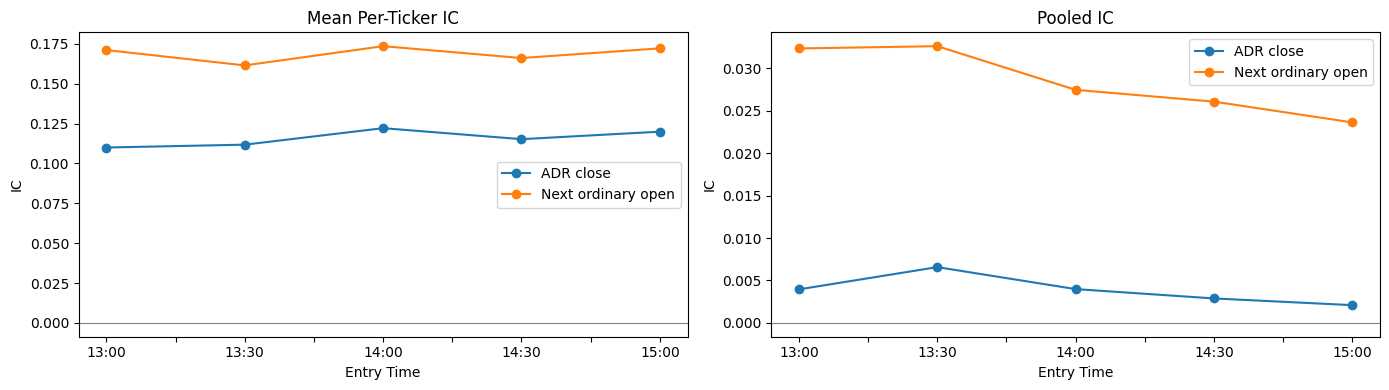

In [7]:
combined_summary = pd.concat(
    {
        'adr_close': close_summary,
        'next_ord_open': next_open_summary,
    },
    names=['horizon', 'entry_time'],
)
display(combined_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

close_summary['mean_per_ticker_ic'].plot(ax=axes[0], marker='o', label='ADR close')
next_open_summary['mean_per_ticker_ic'].plot(ax=axes[0], marker='o', label='Next ordinary open')
axes[0].axhline(0.0, color='gray', linewidth=0.8)
axes[0].set_title('Mean Per-Ticker IC')
axes[0].set_xlabel('Entry Time')
axes[0].set_ylabel('IC')
axes[0].legend()

close_summary['pooled_ic'].plot(ax=axes[1], marker='o', label='ADR close')
next_open_summary['pooled_ic'].plot(ax=axes[1], marker='o', label='Next ordinary open')
axes[1].axhline(0.0, color='gray', linewidth=0.8)
axes[1].set_title('Pooled IC')
axes[1].set_xlabel('Entry Time')
axes[1].set_ylabel('IC')
axes[1].legend()

plt.tight_layout()

adjusted_rows = next_open_panel.loc[
    ~np.isclose(next_open_panel['exit_multiplier'], 1.0, atol=NEXT_OPEN_RATIO_ATOL, rtol=0.0),
    ['date', 'ticker', 'entry_time', 'exit_multiplier'],
].sort_values(['date', 'ticker', 'entry_time'])

print(f'Rows with a next-day ordinary corporate-action adjustment: {len(adjusted_rows):,}')
display(adjusted_rows.head(20))
display(diagnostics.sort_values('adjusted_next_open_days', ascending=False).head(20))


Return magnitude comparison on overlapping observations


,mean_abs_close_return,mean_abs_next_open_return,median_abs_close_return,median_abs_next_open_return,mean_abs_diff,median_abs_diff,mean_abs_ratio,median_abs_ratio,pct_next_open_larger,n_obs
entry_time,,,,,,,,,,
13:00,0.023237,0.020831,0.002964,0.005916,-0.002406,0.002418,1.575364e+11,1.916118,0.693298,61757
13:30,0.022912,0.020677,0.002730,0.005845,-0.002235,0.002532,3.881149e+10,2.043068,0.709124,61779
14:00,0.022594,0.020598,0.002483,0.005754,-0.001996,0.002726,4.218145e+10,2.216701,0.724437,61779
14:30,0.022200,0.020427,0.002196,0.005614,-0.001773,0.002907,2.362514e+10,2.480735,0.742809,61779
15:00,0.021740,0.020257,0.001898,0.005448,-0.001483,0.003103,4.898864e+10,2.816445,0.764774,61779


,ticker,entry_time,mean_abs_close_return,mean_abs_next_open_return,mean_abs_diff,median_abs_ratio,pct_next_open_larger,n_obs
160,RYAAY,13:00,0.005629,0.560081,0.554452,126.344322,0.996436,1403
100,LYG,13:00,0.005366,0.015235,0.009869,2.964978,0.835125,1395
75,HLN,13:00,0.003912,0.011970,0.008058,3.689963,0.851163,645
150,RIO,13:00,0.004164,0.011508,0.007344,2.836131,0.793548,1395
25,BCS,13:00,0.004661,0.011922,0.007261,2.787070,0.779211,1395
90,IHG,13:00,0.004459,0.011627,0.007169,3.016238,0.802151,1395
125,NWG,13:00,0.004351,0.011472,0.007121,2.680375,0.791829,1028
155,RTO,13:00,0.004290,0.011075,0.006785,2.312351,0.750831,602
140,PUK,13:00,0.004578,0.010931,0.006353,2.357249,0.751971,1395
165,SAN,13:00,0.004707,0.010764,0.006057,2.386076,0.758694,1409


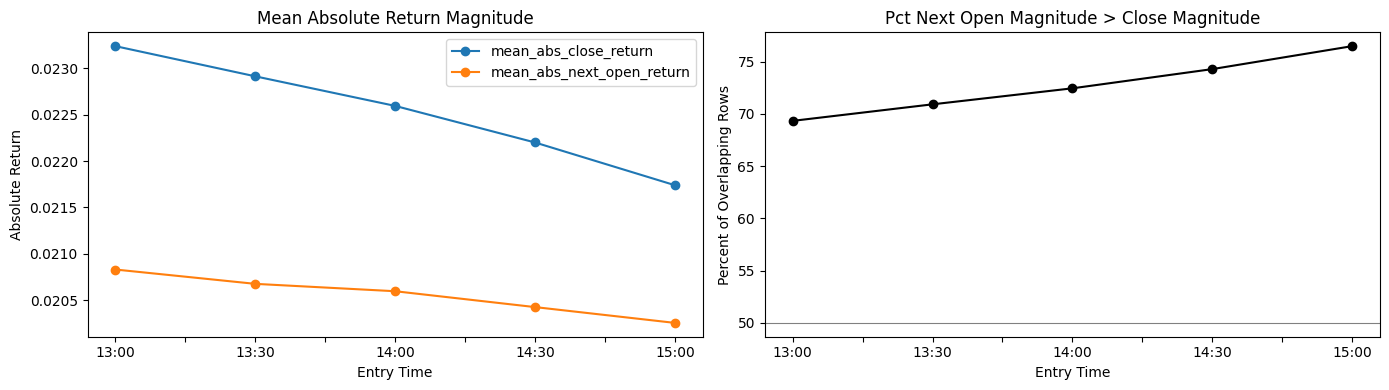

In [8]:
magnitude_comparison = (
    close_panel[['date', 'ticker', 'entry_time', 'realized_return']]
    .rename(columns={'realized_return': 'close_return'})
    .merge(
        next_open_panel[['date', 'ticker', 'entry_time', 'realized_return']].rename(
            columns={'realized_return': 'next_open_return'}
        ),
        on=['date', 'ticker', 'entry_time'],
        how='inner',
    )
)

magnitude_comparison['abs_close_return'] = magnitude_comparison['close_return'].abs()
magnitude_comparison['abs_next_open_return'] = magnitude_comparison['next_open_return'].abs()
magnitude_comparison['abs_diff'] = (
    magnitude_comparison['abs_next_open_return'] - magnitude_comparison['abs_close_return']
)
magnitude_comparison['abs_ratio'] = (
    magnitude_comparison['abs_next_open_return']
    / magnitude_comparison['abs_close_return'].replace(0.0, np.nan)
).replace([np.inf, -np.inf], np.nan)
magnitude_comparison['next_open_larger'] = magnitude_comparison['abs_diff'] > 0

magnitude_summary = (
    magnitude_comparison.groupby('entry_time')
    .agg(
        mean_abs_close_return=('abs_close_return', 'mean'),
        mean_abs_next_open_return=('abs_next_open_return', 'mean'),
        median_abs_close_return=('abs_close_return', 'median'),
        median_abs_next_open_return=('abs_next_open_return', 'median'),
        mean_abs_diff=('abs_diff', 'mean'),
        median_abs_diff=('abs_diff', 'median'),
        mean_abs_ratio=('abs_ratio', 'mean'),
        median_abs_ratio=('abs_ratio', 'median'),
        pct_next_open_larger=('next_open_larger', 'mean'),
        n_obs=('abs_diff', 'size'),
    )
    .sort_index()
)

magnitude_by_ticker = (
    magnitude_comparison.groupby(['ticker', 'entry_time'])
    .agg(
        mean_abs_close_return=('abs_close_return', 'mean'),
        mean_abs_next_open_return=('abs_next_open_return', 'mean'),
        mean_abs_diff=('abs_diff', 'mean'),
        median_abs_ratio=('abs_ratio', 'median'),
        pct_next_open_larger=('next_open_larger', 'mean'),
        n_obs=('abs_diff', 'size'),
    )
    .reset_index()
    .sort_values(['entry_time', 'mean_abs_diff'], ascending=[True, False])
)

print('Return magnitude comparison on overlapping observations')
display(magnitude_summary)
display(magnitude_by_ticker.head(20))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

magnitude_summary[['mean_abs_close_return', 'mean_abs_next_open_return']].plot(
    ax=axes[0],
    marker='o',
)
axes[0].set_title('Mean Absolute Return Magnitude')
axes[0].set_xlabel('Entry Time')
axes[0].set_ylabel('Absolute Return')

(100.0 * magnitude_summary['pct_next_open_larger']).plot(ax=axes[1], marker='o', color='black')
axes[1].axhline(50.0, color='gray', linewidth=0.8)
axes[1].set_title('Pct Next Open Magnitude > Close Magnitude')
axes[1].set_xlabel('Entry Time')
axes[1].set_ylabel('Percent of Overlapping Rows')

plt.tight_layout()


In [ ]:
OUT_DIR = DATA_DIR / 'processed' / 'reports' / 'signal_ic' / 'futures_only_close_vs_next_ord_open'
OUT_DIR.mkdir(parents=True, exist_ok=True)

close_summary.to_csv(OUT_DIR / 'close_summary.csv')
next_open_summary.to_csv(OUT_DIR / 'next_open_summary.csv')
close_ticker_ic.to_csv(OUT_DIR / 'close_ticker_ic.csv', index=False)
next_open_ticker_ic.to_csv(OUT_DIR / 'next_open_ticker_ic.csv', index=False)
combined_summary.to_csv(OUT_DIR / 'combined_summary.csv')
magnitude_summary.to_csv(OUT_DIR / 'magnitude_summary.csv')
magnitude_by_ticker.to_csv(OUT_DIR / 'magnitude_by_ticker.csv', index=False)
diagnostics.to_csv(OUT_DIR / 'ticker_diagnostics.csv', index=False)

print(f'Saved outputs to: {OUT_DIR}')


Saved outputs to: ../data/processed/reports/signal_ic/futures_only_close_vs_next_ord_open
